Physically Feasible Dynamic Parameter Identification of the WAM Robot 7-DOF
===========================================================================

[![DOI](https://zenodo.org/badge/doi/10.5281/zenodo.10534.png)](http://dx.doi.org/10.5281/zenodo.10534)

_Research notebook from the paper:_

**Sousa, Cristóvão D. and Cortesão, Rui, "Physically feasible dynamic parameter identification of the 7-DOF WAM robot," Intelligent Robots and Systems (IROS), 2013 IEEE/RSJ International Conference on , pp.2868-2873, 3-7 Nov. 2013, Tokyo, Japan, doi: [10.1109/IROS.2013.6696762](http://dx.doi.org/10.1109/IROS.2013.6696762)**



------------------------


Authors
-------

- Cristóvão D. Sousa, [crisjss@gmail.com](mailto:crisjss@gmail.com)
- Rui Cortesão, [cortesao@isr.uc.pt](mailto:cortesao@isr.uc.pt)

------------------------


Research Notebook
-----------------

The research is done in [Python](http://www.python.org/) within an [IPython notebook](http://ipython.org/notebook.html) (the *Paper IROS2013 - Phys Feas Dyn Param Ident 7-DOF WAM Rob.ipynb* file).
Data is in *data* folder. Additional Python support code is in *support_funcs* folder

The file *Paper IROS2013 - Phys Feas Dyn Param Ident 7-DOF WAM Rob.html* is a **preview** of the notebook. **It can be seen online at:**

**[Paper IROS2013 - Phys Feas Dyn Param Ident 7-DOF WAM Rob](http://goo.gl/8Xv6Mj)**


Presentation
------------

The slides and movies presented at IROS 2013 are avalable online [here](http://goo.gl/U9YmE5).


Paper Correction
----------------

The published paper presents a physically feasible base parameter solution ("beta star", rightmost column of Table I) which was obtained not taking the friction parameter positiveness constraints into account, contrary to what is shown in equation (17).
In this notebook, both the paper solution (without positiveness constraints on friction parameters) and the correct solution (with positiveness constraints on friction parameters) are computed and presented (to distinguish,  variable names are suffixed with the words "paper" and "correct", respectivelly). Nevertheless, the differences between both solutions (with exception to the corrected friction parameter) are very small, arround 1%. 


How to run the code
-------------------

- clone the git repository (it contains code and data) from https://github.com/cdsousa/IROS2013-Feas-Ident-WAM7
- open the *Paper IROS2013 - Phys Feas Dyn Param Ident 7-DOF WAM Rob.ipynb* notebook with [IPython](http://ipython.org/)
- edit and run the code

Dependencies:

- [Python](http://www.python.org/)
- [IPython](http://ipython.org/)
- [SymPy](http://sympy.org/)
- [Numpy](http://www.numpy.org/)
- [SciPy](http://www.scipy.org/)
- [SymPyBotics](https://github.com/cdsousa/SymPyBotics) (developed by the author Cristóvão D. Sousa)
- [PyLMI-SDP](https://github.com/cdsousa/PyLMI-SDP) (developed by the author Cristóvão D. Sousa)

------------------------


Questions & Feedback
--------------------

Although being open source, the code can lack some better documentation.
Feel free to contact the authors at [crisjss@gmail.com](mailto:crisjss@gmail.com)
We are open to help you to deploy this code or even your own implementation of the proposed algorithms.


------------------------


License
-------

Copyright (c) 2013, Cristóvão Duarte Sousa, Rui Cortesão

All rights reserved.

[![Creative Commons License](http://i.creativecommons.org/l/by-nc-sa/4.0/88x31.png)](http://creativecommons.org/licenses/by-nc-sa/4.0/)
This work is licensed under a [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License](http://creativecommons.org/licenses/by-nc-sa/4.0/)


---------------

---------------

---------------

---------------

# Initializations

In [1]:
datafolder = 'data/'
tmpfolder = 'tmp/'

In [2]:
from sympy import init_printing
init_printing()

%matplotlib inline

1 - Robot Model
===============

In [3]:
import sympybotics

#### Robot Definition

In [4]:
# rbtdef = sympybotics.RobotDef("WAM Arm 7 DOF",
#             [("-pi/2", 0, 0, "q"),
#              ("pi/2", 0, 0, "q"),
#              ("-pi/2", 0.045, 0.55, "q"),
#              ("pi/2", -0.045, 0, "q"),
#              ("-pi/2", 0, 0.3, "q"),
#              ("pi/2", 0, 0, "q"),
#              (0, 0, 0.06, "q")],
#             dh_convention="standard")

# rbtdef = sympybotics.RobotDef("WAM 2-DOF",
#     [("-pi/2", 0, 0, "q"),
#      (0, 0.045, 0.55, "q")],
#     dh_convention="standard"
# )

rbtdef = sympybotics.RobotDef("WAM Arm 4 DOF",
            [("-pi/2", 0, 0, "q"),
             ("pi/2", 0, 0, "q"),
             ("-pi/2", 0.045, 0.55, "q"),
             ("pi/2", -0.045, 0, "q")],
            dh_convention="standard")

# rbtdef = sympybotics.RobotDef("WAM Arm 4 DOF",
#             [(0, 0, 0, "q"),
#              ("-pi/2", 0, 0, "q"),
#              ("pi/2", 0, 0, "q"),
#              ("-pi/2", 0.045, 0.55, "q")],
#             dh_convention="standard")
rbtdef.frictionmodel = {'Coulomb', 'viscous'}

#### Model Generation

In [5]:
import math
import numpy
from math import pi

# Register them in global scope for exec() to see
import builtins
builtins.math = math
builtins.numpy = numpy
builtins.pi = pi

In [6]:
%time rbt = sympybotics.RobotDynCode(rbtdef)
%time rbt.calc_base_parms()

CPU times: user 1.69 s, sys: 110 µs, total: 1.69 s
Wall time: 1.69 s
CPU times: user 730 ms, sys: 44.3 ms, total: 774 ms
Wall time: 533 ms


In [7]:
rbt.geo.T[-1]

⎡(-sin(q₁)⋅sin(q₃) + cos(q₁)⋅cos(q₂)⋅cos(q₃))⋅cos(q₄) - sin(q₂)⋅sin(q₄)⋅cos(q₁
⎢                                                                             
⎢(sin(q₁)⋅cos(q₂)⋅cos(q₃) + sin(q₃)⋅cos(q₁))⋅cos(q₄) - sin(q₁)⋅sin(q₂)⋅sin(q₄)
⎢                                                                             
⎢                  -sin(q₂)⋅cos(q₃)⋅cos(q₄) - sin(q₄)⋅cos(q₂)                 
⎢                                                                             
⎣                                      0                                      

)  -sin(q₁)⋅cos(q₃) - sin(q₃)⋅cos(q₁)⋅cos(q₂)  (-sin(q₁)⋅sin(q₃) + cos(q₁)⋅cos
                                                                              
   -sin(q₁)⋅sin(q₃)⋅cos(q₂) + cos(q₁)⋅cos(q₃)  (sin(q₁)⋅cos(q₂)⋅cos(q₃) + sin(
                                                                              
                sin(q₂)⋅sin(q₃)                                  -sin(q₂)⋅sin(
                                                   

In [8]:
import pickle
with open(tmpfolder + 'robotmodels/wam4_model.pkl', 'wb') as file:
    pickle.dump( rbt, file )

## Base Dynamic Parameters

In [9]:
import pickle
with open(tmpfolder +  'robotmodels/wam4_model.pkl', 'rb' ) as file:
          rbt = pickle.load( file )

In [10]:
rbt.dyn.n_dynparms, rbt.dyn.n_base

In [11]:
rbt.dyn.dynparms.n()

⎡L₁ₓₓ ⎤
⎢     ⎥
⎢L_1xy⎥
⎢     ⎥
⎢L_1xz⎥
⎢     ⎥
⎢L_1yy⎥
⎢     ⎥
⎢L_1yz⎥
⎢     ⎥
⎢L_1zz⎥
⎢     ⎥
⎢ l₁ₓ ⎥
⎢     ⎥
⎢l_1y ⎥
⎢     ⎥
⎢l_1z ⎥
⎢     ⎥
⎢ m₁  ⎥
⎢     ⎥
⎢ fv₁ ⎥
⎢     ⎥
⎢ fc₁ ⎥
⎢     ⎥
⎢L₂ₓₓ ⎥
⎢     ⎥
⎢L_2xy⎥
⎢     ⎥
⎢L_2xz⎥
⎢     ⎥
⎢L_2yy⎥
⎢     ⎥
⎢L_2yz⎥
⎢     ⎥
⎢L_2zz⎥
⎢     ⎥
⎢ l₂ₓ ⎥
⎢     ⎥
⎢l_2y ⎥
⎢     ⎥
⎢l_2z ⎥
⎢     ⎥
⎢ m₂  ⎥
⎢     ⎥
⎢ fv₂ ⎥
⎢     ⎥
⎢ fc₂ ⎥
⎢     ⎥
⎢L₃ₓₓ ⎥
⎢     ⎥
⎢L_3xy⎥
⎢     ⎥
⎢L_3xz⎥
⎢     ⎥
⎢L_3yy⎥
⎢     ⎥
⎢L_3yz⎥
⎢     ⎥
⎢L_3zz⎥
⎢     ⎥
⎢ l₃ₓ ⎥
⎢     ⎥
⎢l_3y ⎥
⎢     ⎥
⎢l_3z ⎥
⎢     ⎥
⎢ m₃  ⎥
⎢     ⎥
⎢ fv₃ ⎥
⎢     ⎥
⎢ fc₃ ⎥
⎢     ⎥
⎢L₄ₓₓ ⎥
⎢     ⎥
⎢L_4xy⎥
⎢     ⎥
⎢L_4xz⎥
⎢     ⎥
⎢L_4yy⎥
⎢     ⎥
⎢L_4yz⎥
⎢     ⎥
⎢L_4zz⎥
⎢     ⎥
⎢ l₄ₓ ⎥
⎢     ⎥
⎢l_4y ⎥
⎢     ⎥
⎢l_4z ⎥
⎢     ⎥
⎢ m₄  ⎥
⎢     ⎥
⎢ fv₄ ⎥
⎢     ⎥
⎣ fc₄ ⎦

In [12]:
rbt.dyn.baseparms.n()

⎡                       L_1yy + L_2zz                       ⎤
⎢                                                           ⎥
⎢                            fv₁                            ⎥
⎢                                                           ⎥
⎢                            fc₁                            ⎥
⎢                                                           ⎥
⎢L₂ₓₓ - L_2zz + L_3zz - 1.1⋅l_3y + 0.300475⋅m₃ + 0.300475⋅m₄⎥
⎢                                                           ⎥
⎢                           L_2xy                           ⎥
⎢                                                           ⎥
⎢                           L_2xz                           ⎥
⎢                                                           ⎥
⎢   L_2yy + L_3zz - 1.1⋅l_3y + 0.300475⋅m₃ + 0.300475⋅m₄    ⎥
⎢                                                           ⎥
⎢                           L_2yz                           ⎥
⎢                                                           ⎥
⎢       

In [13]:
# rbt.dyn.H

In [14]:
rbt.dyn.Pb

⎡0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
⎢                                                                             
⎢0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
⎢                                                                             
⎢0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
⎢                                                                             
⎢1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
⎢                                                                             
⎢0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
⎢                                                                             
⎢0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
⎢                                                                             
⎢0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  

In [15]:
rbt.dyn.base_idxs

In [16]:
import numpy as np

# Step 1: Convert symbolic matrix to NumPy array
Pb_matrix = np.array(rbt.dyn.Pb.tolist(), dtype=np.float64)  # already 0/1
Pb_flat = Pb_matrix.flatten()

# Step 2: Generate C++ code
cpp_array_str = 'double Pb[1440] = {\n'
for i, val in enumerate(Pb_flat):
    cpp_array_str += f'{int(val)}, '  # write as integer 0 or 1
    if (i + 1) % 12 == 0:  # break line every 12 entries
        cpp_array_str += '\n'
cpp_array_str += '};'

with open('Pb_array.cpp', 'w') as f:
    f.write(cpp_array_str)

In [17]:
# rbt.dyn.Pd

In [18]:
# rbt.dyn.Kd

2 - Trajectories and Recorded Data
==================================

In [19]:
import pickle
import sympybotics
import numpy

In [20]:
with open(tmpfolder +  'robotmodels/wam4_model.pkl', 'rb' ) as file:
          rbt = pickle.load( file )

### Plots

In [21]:
# with open(datafolder +  'trajectories/traj_shwfl_abq0.pkl', 'rb' ) as file:
#           s_h_wf_l, a_b_q0 = pickle.load(file)

In [22]:
with open(datafolder + 'trajectories/traj_shwfl_abq0.pkl', 'rb') as file:
    s_h_wf_l, a_b_q0 = pickle.load(file, encoding='latin1')

In [23]:
print(s_h_wf_l)

[5.00000000e+02 4.00000000e-02 3.14159265e-01 5.00000000e+00]


In [24]:
print(a_b_q0) # first 35 are a, then b, finally the last 7 are q0

[-0.22453075 -0.06509415  0.0084825   0.7463596   0.04482256  0.15292831
  0.17945343  0.13698774  0.15005761  0.40428706 -0.06912397  0.64039236
  0.41406122 -0.05345818  0.46419411  0.27601025  0.55370932  0.065848
  0.04071695  0.41272949 -0.17373824  0.89269347  0.45028845 -0.26077073
  0.10794414 -0.16322598  0.22051963 -0.13005116  0.38388683  0.93214031
  0.36874565  0.11058303 -0.13207445  0.39799543  0.28705749  0.09974301
 -0.09950086  0.77226083 -0.28470714  0.06468834  0.0187677  -0.05244391
 -0.40604485  0.43133299 -0.57178278 -0.12185623  0.51881781  0.27173848
  0.15961459 -0.29374854  0.2251367  -0.29917266  0.09730888  0.24762081
  0.07477825 -0.11031733  0.08532278  0.21811307 -0.10056108  0.56254872
 -0.02235595  0.34816564 -0.24721517 -0.1987875  -0.29918626  0.19194917
 -0.39180923 -0.60461852  0.00473514 -0.24540649 -0.24181945  0.03114698
 -0.08510632  1.54641938 -1.67238949 -0.17570127  0.5569734 ]


In [25]:
h = 0.004
decimate = 1
h_plot = h*decimate # downsample it so that it has the frequency of 500 (originally it has been 1000)

with open(datafolder +  'trajectories/traj_4.dat', 'r' ) as file:
          q_ref_orig = numpy.loadtxt(file)
print(q_ref_orig.shape)
q_ref = q_ref_orig
with open(datafolder +  'recdata/rbtlog_4_dof.dat', 'r' ) as file:
          q_raw_orig = numpy.loadtxt(file)
print(q_raw_orig.shape)
s = q_ref_orig.shape[0] // decimate

q_ref = numpy.zeros((s, rbt.dof))
for i in range(s):
    q_ref[i, :] = q_ref_orig[i*decimate, :]
print(q_ref.shape)

(15000, 4)
(15001, 9)
(15000, 4)


In [26]:
si = 0
sf = si + 60/h_plot
t = numpy.arange(sf-si) * h_plot

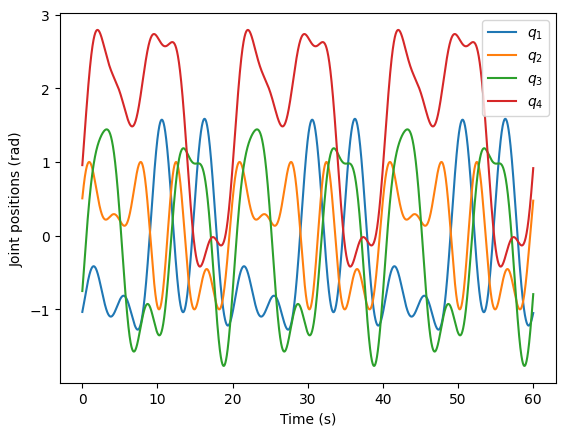

In [27]:
from matplotlib import pyplot as plt
plt.close()

si = int(si)
sf = int(sf)

for i in range(rbt.dof):
    plt.plot(t,q_ref[si:sf,i], label="$q_%d$"%(i+1))
plt.legend()

plt.xlabel("Time (s)")
plt.ylabel("Joint positions (rad)")

plt.show()

3 - Regression Data Processing
==============================

In [28]:
import os
import pickle
import math
import sympy
import numpy
import sympybotics

In [29]:
with open(tmpfolder +  'robotmodels/wam4_model.pkl', 'rb' ) as file:
          rbt = pickle.load( file )

### Data Load

In [30]:
from support_funcs.regr_data_proc import read_data
t_raw, q_raw, tau_raw, t_ref, q_ref = read_data( rbt.dof, 0.004,
                                                datafolder + 'recdata/rbtlog_4_dof.dat',
                                                datafolder + 'trajectories/traj_4.dat')
t_raw = t_raw - t_raw[0]

### Some Plots

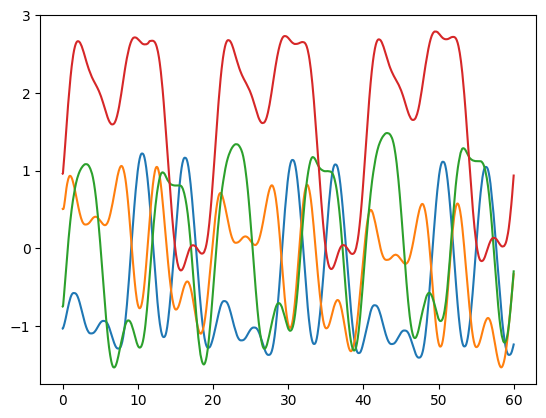

In [31]:
from matplotlib import pyplot as plt
plt.close()

for i in range(q_raw.shape[1]):
    plt.plot(t_raw,q_raw[:,i])

plt.show()

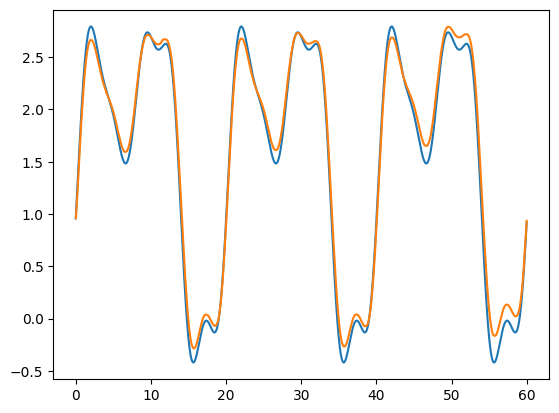

In [32]:
from matplotlib import pyplot as plt
plt.close()

joint = 4
plt.plot(t_ref,q_ref[:,joint-1])
plt.plot(t_raw,q_raw[:,joint-1])

plt.show()

In [33]:
del t_raw, q_raw, tau_raw, t_ref, q_ref

### Parameter Load

In [34]:
# with open(datafolder +  'trajectories/traj_shwfl_abq0.pkl', 'rb' ) as file:
#           s_h_wf_l, a_b_q0 = pickle.load(file)
with open(datafolder + 'trajectories/traj_shwfl_abq0.pkl', 'rb') as file:
    s_h_wf_l, a_b_q0 = pickle.load(file, encoding='latin1')

print(dict(zip(('S', 'h', 'wf', 'L'), s_h_wf_l)))
print('\n')

{'S': 500.0, 'h': 0.04, 'wf': 0.3141592653589793, 'L': 5.0}




### Filter Cut-off Frequency Definition

In [35]:
fc_mult = 10

In [36]:
wf = float(s_h_wf_l[2])
L = float(s_h_wf_l[3])
fc = fc_mult * ( wf / (2*math.pi) * L )
fc

In [37]:
fc_q = fc
fc_dq = fc
fc_ddq = fc

fc_tau = fc

si = int(3/0.001)
sf = -int(1/0.001)-172

### Data Filtering, Differentiation and Regression Data Generation

In [38]:
rec_h = 0.004 # sampling time

In [114]:
from support_funcs.regr_data_proc import read_data, diff_and_filt_data, gen_regr_matrices
from support_funcs.utils import _fprint

t_raw, q_raw, tau_raw, t_ref, q_ref = read_data(dof=rbt.dof, h=rec_h,
                                                rbtlogfile=datafolder + 'recdata/rbtlog_4_dof.dat',
                                                trajreffile=datafolder + 'trajectories/traj_4.dat')

q, dq, ddq, tau = diff_and_filt_data(dof=rbt.dof, h=rec_h,  q_raw=q_raw, tau_raw=tau_raw,
                               fc_q=fc_q, fc_dq=fc_dq, fc_ddq=fc_ddq, fc_tau=fc_tau)

t_raw = t_raw[si:sf]; q_raw = q_raw[si:sf]; tau_raw = tau_raw[si:sf]
q = q[si:sf]; dq = dq[si:sf]; ddq = ddq[si:sf]; tau = tau[si:sf]

t_raw = t_raw - t_raw[0]

t = numpy.array(range(q.shape[0])) * rec_h
print(np.shape(q))
H_S, W, omega, Q1, R1, rho1 = gen_regr_matrices(rbt, q, dq, ddq, tau)
    



_fprint(' (cond=%f)'%numpy.linalg.cond(W))

_fprint('save')

%time \
numpy.savez_compressed(tmpfolder + 'procdata/raw', t=t_raw, q=q_raw, tau=tau_raw);\
numpy.savez_compressed(tmpfolder + 'procdata/proc', t=t, q=q, dq=dq, ddq=ddq, tau=tau); \
numpy.savez_compressed(tmpfolder + 'procdata/regr', W=W, omega=omega, Q1=Q1, R1=R1, rho1=rho1)

# del t_raw, q_raw, tau_raw, t, q, dq, ddq, tau, W, omega, Q1, R1, rho1

(10829, 4)
 (cond=37.423781)
save
CPU times: user 390 ms, sys: 15.4 ms, total: 406 ms
Wall time: 406 ms


In [40]:
W[:4,:]

matrix([[-0.08180129, -1.32239682, -1.        , -1.13391052,  0.53773369,
         -0.08673471,  0.        , -1.42894878,  0.        ,  0.        ,
          0.        ,  0.        , -1.34019537,  0.49749162,  3.04425975,
          0.36286548,  1.89747367,  0.32484392,  0.90661883,  0.        ,
          0.        , -1.16717769, -2.00828597,  1.09312954,  0.12913981,
          3.44834283,  0.2730706 ,  1.31191778,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , -0.87177215,  0.06002731,
         -0.13461655, -1.36534886, -0.05557133, -6.66437907, -7.19876042,
          0.82660888,  1.        ,  0.56481489,  0.84027849,  0.82219634,
         -0.28539169, -0.159051  , -6.35585041,  1.15632898,  0.        ,
          0.        ,  0.04610049, -0.73226533, -1.1883191 , -3.20340433,
          0.2004512 , 10.40317246,  5.82437709,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  

In [41]:
H_S[:4,:] @ np.array(rbt.dyn.Pb) - W[:4,:]

matrix([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=object)

In [42]:
np.array(rbt.dyn.Pb)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 1]], dtype=object)

In [42]:
Tau_total = omega
W_total = W

### Plot

In [43]:
raw = numpy.load(tmpfolder + 'procdata/raw.npz')
tau_raw = raw['tau']
q_raw = raw['q']
del raw
proc = numpy.load(tmpfolder + 'procdata/proc.npz')
t = proc['t']
tau = proc['tau']
q = proc['q']
dq = proc['dq']
del proc

In [44]:
q.shape

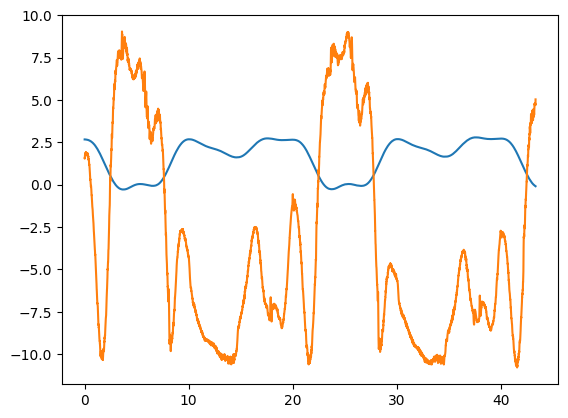

In [147]:
from matplotlib import pyplot as plt
plt.close()

joint = 4
firsts = 20000
plt.plot(t[:firsts],q_raw[:,joint-1][:firsts])
#plt.plot(t[:firsts],q[:,joint-1][:firsts])
#plt.plot(t[:firsts],dq[:,joint-1][:firsts])
plt.plot(t[:firsts],tau_raw[:,joint-1][:firsts])

plt.show()

In [46]:
del t, q, dq, tau, q_raw, tau_raw

4 - Near-zero Velocity Data Elimination
=======================================

In [47]:
import numpy

In [48]:
proc = numpy.load(tmpfolder + 'procdata/proc.npz')
dq = proc['dq']
regr = numpy.load(tmpfolder + 'procdata/regr.npz')
omega = numpy.matrix(regr['omega'])
W = numpy.matrix(regr['W'])
del proc, regr

In [49]:
w = omega
v = dq.flatten()
s = len(v)

In [50]:
def selected_regression( obs_mat, output_vec, select_list=None ):
    
    if select_list is None:
        A = obs_mat[:,:]
        b = output_vec[:,:]
    else:
        A = obs_mat[select_list,:]
        b = output_vec[select_list,:]
    
    num = len(b)
    q1,r1 = numpy.linalg.qr(A)
    b1 = q1.T*b
    cond = numpy.linalg.cond(r1)
    x = numpy.linalg.inv(r1.T * r1) * r1.T * b1
    se = b - A*x
    err = numpy.linalg.norm(se)
    relerr = err / numpy.linalg.norm(b)
    mse = err**2/(num-A.shape[1])
    
    return x,se,{'num':num,'cond':cond,'mse':mse, 'relerr':relerr}

In [51]:
list_v_threshold = numpy.arange(0.0, 0.02, 0.002).tolist() + numpy.arange(0.02, 0.08+1e-10, 0.02).tolist()

In [52]:
selections = []
list_props = []
v_db_unc_regr = []
v_num = []
v_cond = []
v_relerr = []
v_mse = []
for idx, v_threshold in enumerate(list_v_threshold):
    r_vel = []
    if True:
        for i,vi in enumerate(v):
            if numpy.abs(vi) >= v_threshold:
                r_vel.append( i )
    else:                
        for i in range(len(v)/rbt.dof):
            elimin = False
            for l in range(rbt.dof):
                vi = v[i*rbt.dof+l]
                if numpy.abs(vi) < v_threshold:
                    elimin = True
            if not elimin:
                r_vel += [i*rbt.dof+l for l in range(rbt.dof)]
    selections.append(r_vel)
    db_unc_regr_vel,se,props = selected_regression( W, w, r_vel )
    list_props.append(props)
    v_db_unc_regr.append(db_unc_regr_vel)
    v_num.append(props['num'])
    v_cond.append(props['cond'])
    v_relerr.append(props['relerr'])
    v_mse.append(props['mse'])
    
    print("%d %.3f %s"%(idx, v_threshold, props))

0 0.000 {'num': 43316, 'cond': 37.42378117407775, 'mse': 0.6632210564065518, 'relerr': 0.06806935162140884}
1 0.002 {'num': 42978, 'cond': 37.52721639760651, 'mse': 0.6462916051955332, 'relerr': 0.0670269367487859}
2 0.004 {'num': 42603, 'cond': 37.68808911206298, 'mse': 0.6198255996338738, 'relerr': 0.06544576723947379}
3 0.006 {'num': 42279, 'cond': 37.79935141982071, 'mse': 0.6073936801180676, 'relerr': 0.06464500008331092}
4 0.008 {'num': 42060, 'cond': 37.90035257850513, 'mse': 0.5998820954341612, 'relerr': 0.0641525683699661}
5 0.010 {'num': 41846, 'cond': 37.98926793491792, 'mse': 0.5938005985329227, 'relerr': 0.06376274197421854}
6 0.012 {'num': 41630, 'cond': 38.07439876179821, 'mse': 0.5885954618208485, 'relerr': 0.06342758049337481}
7 0.014 {'num': 41442, 'cond': 38.14152371073598, 'mse': 0.5859669892430912, 'relerr': 0.0632230434724493}
8 0.016 {'num': 41267, 'cond': 38.198761094012795, 'mse': 0.5833328255488074, 'relerr': 0.06304356567887541}
9 0.018 {'num': 41098, 'cond':


8 0.016 {'relerr': 0.055632994395873152, 'mse': 0.14724670987205066, 'num': 391077, 'cond': 48.76514081953475}


9 0.018 {'relerr': 0.055537544791336789, 'mse': 0.14707341213600827, 'num': 389130, 'cond': 48.89150137276274}


10 0.020 {'relerr': 0.055461842440442236, 'mse': 0.14699404582759037, 'num': 387294, 'cond': 49.020702056156416}


11 0.040 {'relerr': 0.055083634995312637, 'mse': 0.14699394960383888, 'num': 372967, 'cond': 51.06448480406862}


12 0.060 {'relerr': 0.05481760216003656, 'mse': 0.14661501527769974, 'num': 362076, 'cond': 53.381795030501316}


13 0.080 {'relerr': 0.054450672701337931, 'mse': 0.14498479649139431, 'num': 353395, 'cond': 54.590336383529625}

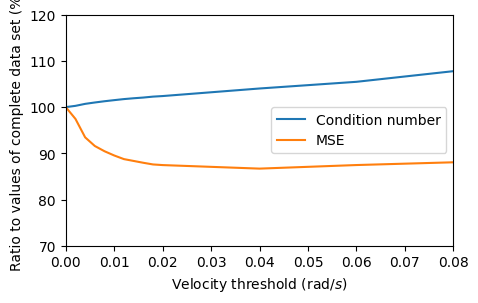

In [53]:
from matplotlib import pyplot as plt

plt.figure(figsize=(5,3))
plt.plot(list_v_threshold,v_cond/v_cond[0]*100, label='Condition number')
plt.plot(list_v_threshold,v_mse/v_mse[0]*100, label='MSE')
#plt.plot(list_v_threshold,v_relerr/v_relerr[0]*100, label='rel err')
plt.legend(loc='right')
plt.axis([0.0,0.08,70,120])
plt.ylabel('Ratio to values of complete data set (%)')
plt.xlabel('Velocity threshold ($\mathrm{rad}/s$)')

plt.show()

In [54]:
threshold_idx = 5

In [55]:
(v_cond[threshold_idx] / v_cond[0]  - 1) * 100.0

In [56]:
(v_mse[threshold_idx]/v_mse[0] - 1) *100

In [57]:
v_cond[threshold_idx]

In [58]:
select = selections[threshold_idx]
threshold = list_v_threshold[threshold_idx]

W_n0v = W[select,:]
omega_n0v = omega[select,:]
    
Q1_n0v,R1_n0v = numpy.linalg.qr(W_n0v)
rho1_n0v = Q1_n0v.T*omega_n0v

In [59]:
%time \
numpy.savez_compressed(tmpfolder + 'procdata/regr_n0v', W=W_n0v, omega=omega_n0v, Q1=Q1_n0v, R1=R1_n0v, rho1=rho1_n0v)

del W, omega, W_n0v, omega_n0v, Q1_n0v, R1_n0v, rho1_n0v

CPU times: user 339 ms, sys: 6.89 ms, total: 346 ms
Wall time: 344 ms


5 - Dynamic Parameter Estimation
================================

In [60]:
import os
import pickle
import sympy
import numpy
import time

import sympybotics
import lmi_sdp

from lmi_sdp import init_lmi_latex_printing
init_lmi_latex_printing()

In [61]:
with open(tmpfolder +  'robotmodels/wam4_model.pkl', 'rb' ) as file:
          rbt = pickle.load( file )

In [62]:
epsilon_safemargin = 1e-30

## LMI Matrix Definitions

In [63]:
dof = rbt.dof

delta = rbt.dyn.dynparms
n_delta = rbt.dyn.n_dynparms

beta = rbt.dyn.baseparms.n()
n_beta = rbt.dyn.n_base
beta_symbs = sympy.Matrix([sympy.Symbol('beta'+str(i+1),real=True) for i in range(n_beta)])

delta_d = (rbt.dyn.Pd.T*delta)
n_delta_d = len(delta_d)

K = rbt.dyn.Pb.T + rbt.dyn.Kd * rbt.dyn.Pd.T

In [64]:
from support_funcs.utils import skew, mrepl
from sympy import BlockMatrix, Matrix, eye, Identity
I = Identity
S = skew

In [65]:
D_inertia_blocks = []
for i in range(dof):
    L = rbt.rbtdef.L[i]
    l = rbt.rbtdef.l[i]
    m = rbt.rbtdef.m[i]
    Di = BlockMatrix([[L,    S(l).T],
                      [S(l), I(3)*m]])
    D_inertia_blocks.append(Di.as_explicit())

In [66]:
D_inertia_blocks[0]

⎡L₁ₓₓ   L_1xy  L_1xz    0    l_1z  -l_1y⎤
⎢                                       ⎥
⎢L_1xy  L_1yy  L_1yz  -l_1z   0     l₁ₓ ⎥
⎢                                       ⎥
⎢L_1xz  L_1yz  L_1zz  l_1y   -l₁ₓ    0  ⎥
⎢                                       ⎥
⎢  0    -l_1z  l_1y    m₁     0      0  ⎥
⎢                                       ⎥
⎢l_1z     0    -l₁ₓ     0     m₁     0  ⎥
⎢                                       ⎥
⎣-l_1y   l₁ₓ     0      0     0     m₁  ⎦

In [67]:
D_other_blocks = []
for i in range(dof):
    D_other_blocks.append( Matrix([rbt.rbtdef.fv[i]]) )
    D_other_blocks.append( Matrix([rbt.rbtdef.fc[i]]) )

In [68]:
D_blocks = D_inertia_blocks + D_other_blocks

In [69]:
D_blocks

⎡⎡L₁ₓₓ   L_1xy  L_1xz    0    l_1z  -l_1y⎤  ⎡L₂ₓₓ   L_2xy  L_2xz    0    l_2z 
⎢⎢                                       ⎥  ⎢                                 
⎢⎢L_1xy  L_1yy  L_1yz  -l_1z   0     l₁ₓ ⎥  ⎢L_2xy  L_2yy  L_2yz  -l_2z   0   
⎢⎢                                       ⎥  ⎢                                 
⎢⎢L_1xz  L_1yz  L_1zz  l_1y   -l₁ₓ    0  ⎥  ⎢L_2xz  L_2yz  L_2zz  l_2y   -l₂ₓ 
⎢⎢                                       ⎥, ⎢                                 
⎢⎢  0    -l_1z  l_1y    m₁     0      0  ⎥  ⎢  0    -l_2z  l_2y    m₂     0   
⎢⎢                                       ⎥  ⎢                                 
⎢⎢l_1z     0    -l₁ₓ     0     m₁     0  ⎥  ⎢l_2z     0    -l₂ₓ     0     m₂  
⎢⎢                                       ⎥  ⎢                                 
⎣⎣-l_1y   l₁ₓ     0      0     0     m₁  ⎦  ⎣-l_2y   l₂ₓ     0      0     0   

 -l_2y⎤  ⎡L₃ₓₓ   L_3xy  L_3xz    0    l_3z  -l_3y⎤  ⎡L₄ₓₓ   L_4xy  L_4xz    0 
      ⎥  ⎢                                       ⎥ 

In [70]:
print(len(D_blocks))

12


## LMI Definitions

In [71]:
from lmi_sdp import LMI_PD, LMI

In [72]:
LMIs = list(map(LMI_PD, D_blocks))

In [73]:
LMIs[10]

[fv₄] > 0

In [74]:
LMIs_marg = list(map(lambda lm: LMI(lm, epsilon_safemargin*eye(lm.shape[0])) , D_blocks))

In [75]:
LMIs_marg[0]

⎡L₁ₓₓ   L_1xy  L_1xz    0    l_1z  -l_1y⎤   ⎡1.0e-30     0        0        0  
⎢                                       ⎥   ⎢                                 
⎢L_1xy  L_1yy  L_1yz  -l_1z   0     l₁ₓ ⎥   ⎢   0     1.0e-30     0        0  
⎢                                       ⎥   ⎢                                 
⎢L_1xz  L_1yz  L_1zz  l_1y   -l₁ₓ    0  ⎥   ⎢   0        0     1.0e-30     0  
⎢                                       ⎥ ≥ ⎢                                 
⎢  0    -l_1z  l_1y    m₁     0      0  ⎥   ⎢   0        0        0     1.0e-3
⎢                                       ⎥   ⎢                                 
⎢l_1z     0    -l₁ₓ     0     m₁     0  ⎥   ⎢   0        0        0        0  
⎢                                       ⎥   ⎢                                 
⎣-l_1y   l₁ₓ     0      0     0     m₁  ⎦   ⎣   0        0        0        0  

      0        0   ⎤
                   ⎥
      0        0   ⎥
                   ⎥
      0        0   ⎥
                   ⎥
0   

In [76]:
LMIs_marg[0].canonical()

⎡L₁ₓₓ - 1.0e-30       L_1xy            L_1xz            0            l_1z     
⎢                                                                             
⎢    L_1xy       L_1yy - 1.0e-30       L_1yz          -l_1z           0       
⎢                                                                             
⎢    L_1xz            L_1yz       L_1zz - 1.0e-30      l_1y          -l₁ₓ     
⎢                                                                             
⎢      0              -l_1z            l_1y        m₁ - 1.0e-30       0       
⎢                                                                             
⎢     l_1z              0              -l₁ₓ             0        m₁ - 1.0e-30 
⎢                                                                             
⎣    -l_1y             l₁ₓ               0              0             0       

    -l_1y    ⎤    
             ⎥    
     l₁ₓ     ⎥    
             ⎥    
      0      ⎥    
             ⎥ ≥ 0
      0      ⎥  

In [77]:
LMIs_paper = list(map(LMI_PD, D_inertia_blocks))
LMIs_marg_paper = list(map(lambda lm: LMI(lm, epsilon_safemargin*eye(lm.shape[0])) , D_inertia_blocks))

## SDP Solver Interfaces

### [SDPA](http://sdpa.sourceforge.net/)

In [78]:
def sdpa(objf, lmis, variables):
    sdpadat = lmi_sdp.to_sdpa_sparse(objf, lmis, variables)
    with open(tmpfolder + 'sdpa_dat/sdp.dat-s', 'w') as f:
        f.write(sdpadat)
    
    stdout = !sdpa -ds "$tmpfolder"sdpa_dat/sdp.dat-s -o "$tmpfolder"sdpa_dat/sdpa.out -p "$tmpfolder"sdpa_dat/param.sdpa

    outfile = !cat "$tmpfolder"sdpa_dat/sdpa.out
    print("\n".join(outfile))

    solstart = outfile.index('xVec = ')
    print('\n'.join(outfile[:solstart]))
    
    sol = [float(v) for v in outfile[solstart + 1].replace('{', '').replace('}', '').split(',')]
    return numpy.matrix(sol).T

### [CSDP](https://projects.coin-or.org/Csdp/)

In [79]:
def csdp(objf, lmis, variables):
    sdpadat = lmi_sdp.to_sdpa_sparse(objf, lmis, variables)
    with open(tmpfolder + 'sdpa_dat/sdp.dat-s', 'w') as f:
        f.write(sdpadat)
    
    stdout = !cd "$tmpfolder"sdpa_dat; csdp sdp.dat-s csdp.out
    print('\n'.join(stdout))

    outfile = !cat "$tmpfolder"sdpa_dat/csdp.out
    sol = [float(v) for v in outfile[0].split()]
    return numpy.matrix(sol).T

### [CVXOPT CONELP](http://abel.ee.ucla.edu/cvxopt/userguide/coneprog.html#cvxopt.solvers.sdp)

In [80]:
def cvxopt_conelp(objf, lmis, variables):
    import cvxopt.solvers
    c, Gs, hs = lmi_sdp.to_cvxopt(objf, lmis, variables)
    tic = time.time()
    sdpout = cvxopt.solvers.sdp(c, Gs=Gs, hs=hs)
    toc = time.time()
    print(sdpout['status'])
    print('Elapsed time: %.2f s'%(toc-tic))
    return numpy.matrix(sdpout['x'])

### [Raw SDPA file](http://plato.asu.edu/ftp/sdpa_format.txt)

Can be solved online with the [NEOS SDPA Solver](http://www.neos-server.org/neos/solvers/sdp:SDPA/SPARSE_SDPA.html)

In [81]:
def sdpa_file(objf, lmis, variables):
    sdpadat = lmi_sdp.to_sdpa_sparse(objf, lmis, variables)
    with open(tmpfolder + 'sdpa_dat/sdpa_input.dat-s', 'w') as f:
        f.write(sdpadat)
        
    print("SDPA file saved at: %ssdpa_dat/sdpa_input.dat-s"%tmpfolder)

--------------

Setting the default SDP solver:

In [82]:
solve_sdp = sdpa

## OLS Regression ($\hat{\beta}$)

In [83]:
regr_mats = numpy.load(tmpfolder + 'procdata/regr_n0v.npz')
W = numpy.matrix(regr_mats['W'])
omega = numpy.matrix(regr_mats['omega'])
R1 = numpy.matrix(regr_mats['R1'])
rho1 = numpy.matrix(regr_mats['rho1'])

In [84]:
omega.shape[0] / rbt.dof

In [85]:
W.shape

In [86]:
numpy.linalg.cond(W)

In [87]:
%time beta_ols = (R1.T * R1).I * R1.T * rho1

CPU times: user 570 µs, sys: 103 µs, total: 673 µs
Wall time: 749 µs


In [88]:
numpy.savetxt(tmpfolder + 'solutions/beta_ols.dat', beta_ols)

In [89]:
rho2_norm_sqr = numpy.linalg.norm(omega - W * beta_ols)**2

## Feasible Parameter Estimation with Ordinary Least Squares ($\delta^\star$)

In [90]:
u = sympy.Symbol('u')
U_rho = BlockMatrix([[Matrix([u - rho2_norm_sqr]), (rho1 - R1*K*delta).T],
                     [rho1 - R1*K*delta,                       I(n_beta)]])
U_rho = U_rho.as_explicit()

In [91]:
lmis_fpe_ols_paper = [LMI(U_rho)] + LMIs_marg_paper
lmis_fpe_ols_correct = [LMI(U_rho)] + LMIs_marg

In [92]:
variables_fpe_ols = [u] + list(delta)

In [93]:
objf_fpe_ols = u

In [94]:
sol_fpe_ols_paper = sdpa(objf_fpe_ols, lmis_fpe_ols_paper, variables_fpe_ols)

SDPA start at [Wed Jun 25 12:10:00 2025]
param  is tmp/sdpa_dat/param.sdpa 
data   is tmp/sdpa_dat/sdp.dat-s  : sparse
out    is tmp/sdpa_dat/sdpa.out
NumThreads  is set as 1
Schur computation : DENSE 
   mu      thetaP  thetaD  objP      objD      alphaP  alphaD  beta 
 0 1.0e+04 1.0e+00 1.0e+00 -0.00e+00 +2.48e+06 8.1e-01 8.7e-01 2.00e-01
 1 2.4e+03 1.9e-01 1.3e-01 +2.02e+04 +3.50e+05 8.6e-01 8.6e-01 2.00e-01
 2 5.3e+02 2.8e-02 1.9e-02 +2.43e+04 +6.58e+04 8.2e-01 8.6e-01 2.00e-01
 3 1.6e+02 4.9e-03 2.6e-03 +2.49e+04 +2.66e+04 5.4e-01 8.8e-01 2.00e-01
 4 5.7e+01 2.3e-03 3.1e-04 +2.49e+04 +2.41e+04 2.5e-01 2.3e-01 2.00e-01
 5 4.7e+01 1.7e-03 2.4e-04 +2.50e+04 +2.50e+04 2.4e-01 2.3e-01 2.00e-01
 6 4.1e+01 1.3e-03 1.9e-04 +2.53e+04 +2.58e+04 4.0e-01 2.3e-01 2.00e-01
 7 3.4e+01 7.7e-04 1.4e-04 +2.60e+04 +2.65e+04 5.8e-01 2.8e-01 2.00e-01
 8 2.2e+01 3.2e-04 1.0e-04 +2.68e+04 +2.72e+04 6.5e-01 5.4e-01 2.00e-01
 9 1.2e+01 1.1e-04 4.6e-05 +2.76e+04 +2.76e+04 9.8e-01 7.2e-01 2.00e-01
10 4.9e+0

In [95]:
sol_fpe_ols_correct = sdpa(objf_fpe_ols, lmis_fpe_ols_correct, variables_fpe_ols)

SDPA start at [Wed Jun 25 12:10:03 2025]
param  is tmp/sdpa_dat/param.sdpa 
data   is tmp/sdpa_dat/sdp.dat-s  : sparse
out    is tmp/sdpa_dat/sdpa.out
NumThreads  is set as 1
Schur computation : DENSE 
   mu      thetaP  thetaD  objP      objD      alphaP  alphaD  beta 
 0 1.0e+04 1.0e+00 1.0e+00 -0.00e+00 +2.48e+06 8.1e-01 8.7e-01 2.00e-01
 1 2.5e+03 1.9e-01 1.3e-01 +2.02e+04 +3.49e+05 8.6e-01 8.6e-01 2.00e-01
 2 5.5e+02 2.8e-02 1.9e-02 +2.43e+04 +6.41e+04 8.2e-01 8.6e-01 2.00e-01
 3 1.7e+02 4.9e-03 2.6e-03 +2.49e+04 +2.54e+04 5.4e-01 8.8e-01 2.00e-01
 4 6.0e+01 2.3e-03 3.2e-04 +2.49e+04 +2.36e+04 2.5e-01 2.3e-01 2.00e-01
 5 4.9e+01 1.7e-03 2.4e-04 +2.50e+04 +2.46e+04 2.5e-01 2.4e-01 2.00e-01
 6 4.2e+01 1.3e-03 1.9e-04 +2.53e+04 +2.55e+04 4.0e-01 2.4e-01 2.00e-01
 7 3.4e+01 7.6e-04 1.4e-04 +2.60e+04 +2.63e+04 5.9e-01 2.9e-01 2.00e-01
 8 2.3e+01 3.1e-04 1.0e-04 +2.69e+04 +2.70e+04 6.6e-01 5.4e-01 2.00e-01
 9 1.3e+01 1.1e-04 4.7e-05 +2.76e+04 +2.75e+04 9.9e-01 7.2e-01 2.00e-01
10 5.1e+0

In [96]:
u_star_paper = sol_fpe_ols_paper[0,0]
delta_star_paper = numpy.matrix(sol_fpe_ols_paper[1:])

u_star_correct = sol_fpe_ols_correct[0,0]
delta_star_correct = numpy.matrix(sol_fpe_ols_correct[1:])

In [97]:
beta_star_paper = numpy.array(K * delta_star_paper).astype(float)

beta_star_correct = numpy.array(K * delta_star_correct).astype(float)

In [101]:
Tau_total

matrix([[ -5.40002203],
        [-20.25849267],
        [  3.26378397],
        ...,
        [ 43.99074269],
        [  0.8236675 ],
        [  4.98237329]])

In [110]:
np.linalg.norm(W_total @ beta_star_correct - Tau_total)/len(Tau_total)

In [112]:
np.linalg.norm(H_S * delta_star_correct - Tau_total)/len(Tau_total)

In [99]:
numpy.linalg.norm(beta_star_paper - beta_star_correct)

In [100]:
print(" B*paper    B*correct\n")
for i in range(beta_star_correct.shape[0]):
    print("% f  % f"%(beta_star_paper[i], beta_star_correct[i]))

 B*paper    B*correct

 0.099805   0.099797
 2.012737   2.012744
 2.978249   2.978243
 1.273034   1.273047
 0.062617   0.062618
-0.141069  -0.141070
 1.193065   1.193074
-0.044307  -0.044301
 0.076942   0.076941
 3.147329   3.147336
 2.636911   2.636908
 0.734760   0.734761
 0.085706   0.085710
 0.019169   0.019168
 0.078494   0.078497
 0.017294   0.017293
 0.172421   0.172434
 0.153198   0.153199
-0.015829  -0.015831
 1.625746   1.625741
 0.620642   0.620642
 0.312740   0.312738
 0.050033   0.050036
 0.027670   0.027671
 0.309771   0.309771
-0.060911  -0.060915
-0.207518  -0.207518
 1.016344   1.016344
 0.464578   0.464578
 0.570518   0.570520


In [101]:
numpy.savetxt(tmpfolder + 'solutions/delta_star_correct.dat', delta_star_correct)
numpy.savetxt(tmpfolder + 'solutions/beta_star_correct.dat', beta_star_correct)
numpy.savetxt(tmpfolder + 'solutions/delta_star_paper.dat', delta_star_paper)
numpy.savetxt(tmpfolder + 'solutions/beta_star_paper.dat', beta_star_paper)

# 6 - Solution Double Check

### 1 - LMI Definiteness Test

In [102]:
def  test_lmi_matrix_psd(delta_solution):
    dict_subs = dict(zip(delta, delta_solution))

    test = 'ok'
    for Di in D_blocks:
            m = numpy.matrix(mrepl(Di, dict_subs)).astype(float)
            for v in numpy.linalg.eigvals( m ):
                if v <= 0.0:
                    print(v)
                    test = 'fail'
    print(test)

In [103]:
test_lmi_matrix_psd(numpy.loadtxt(tmpfolder + 'solutions/delta_star_correct.dat').flatten().tolist())

ok


### 2 - Inertia Matrix Definiteness Test

In [104]:
def test_mass_matrix_psd(beta_solution):
    K = rbt.dyn.Pb.T + rbt.dyn.Kd * rbt.dyn.Pd.T
    A = numpy.matrix(K).astype(float)
    b = numpy.matrix(beta_solution).astype(float)
    x = numpy.linalg.pinv(A) * b
    d_test = x
    
    M_func_def = sympybotics.robotcodegen.robot_code_to_func( 'python', rbt.M_code, 'M', 'M_func', rbt.rbtdef)
    exec(M_func_def, globals())
    global sin, cos
    from math import sin, cos
    
    ntests = 10000
    
    ok = 0
    nok = 0
    for i in range(ntests):
        q_test = numpy.random.rand(rbt.dof)
        M_out = M_func( numpy.array(d_test).flatten().tolist(), q_test)
        M = numpy.matrix(M_out).reshape((rbt.dof,rbt.dof))
        try:
            c = numpy.linalg.cholesky(M)
        except:
            nok += 1
            continue
        ok += 1
        
    print ('ok     %8i  %3i%%'%(ok, 100.0*ok/ntests))
    print ('not ok %8i  %3i%%'%(nok, 100.0*nok/ntests))
    if nok > 0 :
        print('\nNot PSD -> Not feasible!')
    else:
        print('\nSeems feasible.')

In [105]:
beta_ols = numpy.matrix(numpy.loadtxt(tmpfolder + 'solutions/beta_ols.dat')).T
test_mass_matrix_psd(beta_ols)

ok            0    0%
not ok    10000  100%

Not PSD -> Not feasible!


In [106]:
beta_starextra = numpy.matrix(numpy.loadtxt(tmpfolder + 'solutions/beta_star_correct.dat')).T
test_mass_matrix_psd(beta_starextra)

ok        10000  100%
not ok        0    0%

Seems feasible.


In [107]:
regressor_func_def = sympybotics.robotcodegen.robot_code_to_func('c', rbt.H_code, 'H', 'regressor_func', rbt.rbtdef)
with open('regressor_func.cpp', 'w') as f:
    f.write(regressor_func_def)
print(regressor_func_def)

void regressor_func( double* H, const double* q, const double* dq, const double* ddq )
{
  double x0 = -ddq[0];
  double x1 = -dq[0];
  double x2 = cos(q[1]);
  double x3 = -x2;
  double x4 = x1*x3;
  double x5 = -x4;
  double x6 = dq[1]*x5;
  double x7 = sin(q[1]);
  double x8 = x0*x7 + x6;
  double x9 = x1*x7;
  double x10 = dq[1]*x9;
  double x11 = -x10;
  double x12 = x5*x9;
  double x13 = ((x9)*(x9));
  double x14 = ((dq[1])*(dq[1]));
  double x15 = x0*x3 + x10;
  double x16 = ((x4)*(x4));
  double x17 = x4*x9;
  double x18 = dq[1]*x4;
  double x19 = 9.8100000000000005*x2;
  double x20 = -9.8100000000000005*x7;
  double x21 = -x20;
  double x22 = cos(q[2]);
  double x23 = sin(q[2]);
  double x24 = ddq[1]*x23;
  double x25 = x22*x8;
  double x26 = dq[1]*x22;
  double x27 = x23*x9;
  double x28 = -x27;
  double x29 = x26 + x28;
  double x30 = -dq[2];
  double x31 = -x30;
  double x32 = x24 + x25 + x29*x31;
  double x33 = dq[1]*x23;
  double x34 = x22*x9;
  double x35 = x33 + x34;
  

In [119]:
regressor_func_def_python = sympybotics.robotcodegen.robot_code_to_func('python', rbt.H_code, 'H', 'regressor_func', rbt.rbtdef)
with open('regressor_func.py', 'w') as f:
    f.write(regressor_func_def_python)
print(regressor_func_def_python)

def regressor_func(q, dq, ddq):
#
    H = [0]*192
#
    x0 = -ddq[0]
    x1 = -dq[0]
    x2 = math.cos(q[1])
    x3 = -x2
    x4 = x1*x3
    x5 = -x4
    x6 = dq[1]*x5
    x7 = math.sin(q[1])
    x8 = x0*x7 + x6
    x9 = x1*x7
    x10 = dq[1]*x9
    x11 = -x10
    x12 = x5*x9
    x13 = x9**2
    x14 = dq[1]**2
    x15 = x0*x3 + x10
    x16 = x4**2
    x17 = x4*x9
    x18 = dq[1]*x4
    x19 = 9.81*x2
    x20 = -9.81*x7
    x21 = -x20
    x22 = math.cos(q[2])
    x23 = math.sin(q[2])
    x24 = ddq[1]*x23
    x25 = x22*x8
    x26 = dq[1]*x22
    x27 = x23*x9
    x28 = -x27
    x29 = x26 + x28
    x30 = -dq[2]
    x31 = -x30
    x32 = x24 + x25 + x29*x31
    x33 = dq[1]*x23
    x34 = x22*x9
    x35 = x33 + x34
    x36 = -x35
    x37 = x30 + x5
    x38 = x36*x37
    x39 = -x23
    x40 = x29*x35
    x41 = -x40
    x42 = -ddq[2] - x15
    x43 = x41 + x42
    x44 = x35**2
    x45 = x37**2
    x46 = -x45
    x47 = x44 + x46
    x48 = x29*x37
    x49 = x32 + x48
    x50 = -x49
    x51 = x35*x37


In [143]:
exec(sympybotics.robotcodegen.robot_code_to_func('python', rbt.H_code, 'H', 'regressor_func', rbt.rbtdef))
W_now = np.array(regressor_func(np.array([0,0,0,0]),np.array([0,0,0,0]),np.array([0,0,0,0]))).reshape(4,48) @ np.array(rbt.dyn.Pb)
print(W_now.shape)
# np.array(regressor_func(np.array([0,0,0,0]),np.array([0,0,0,0]),np.array([0,0,0,0])))

(4, 30)


In [128]:
H_S[:4,:]

matrix([[ 0.        ,  0.        ,  0.        , -0.08180129,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         -1.32239682, -1.        , -1.13391052,  0.53773369, -0.08673471,
          0.        , -1.42894878,  1.05210923,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        , -1.34019537,
          0.49749162,  3.04425975,  0.36286548,  1.89747367,  0.20628485,
          0.32484392,  1.22491445,  0.90661883, -0.32954249,  0.        ,
          0.        , -1.16717769, -2.00828597,  1.09312954,  0.12913981,
          3.44834283,  0.18984779,  0.2730706 ,  0.81624596,  1.31191778,
         -0.34247661,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        , -0.87177215,  0.06002731, -0.13461655,
         -1.36534886, -0.05557133,  0.87177215, -6.66437907,  0

7 - Tables
==========

In [109]:
import numpy as np
import sympybotics
import pickle

from collections import OrderedDict
from support_funcs.utils import ListTable

In [110]:
with open(tmpfolder +  'robotmodels/wam4_model.pkl', 'rb' ) as file:
          rbt = pickle.load( file )

In [111]:
def analyse(W, omega, R1, beta):
    from numpy import matrix, mean
    from numpy.linalg import cond, norm
    
    p = dict()
    
    n = W.shape[0]
    
    omega_norm = norm(omega)
    omega_mean = mean(omega)
    
    p['err'] = norm(omega - W * beta)
    p['merr'] = p['err'] / n
    
    p['se'] = p['err']**2
    p['mse'] = p['se']/(n-W.shape[1])
    p['rmse'] = p['mse']**0.5
    
    C = p['mse'] * (R1.T * R1).I
    p['sd'] = np.sqrt(C.diagonal()).T
    p['sd%'] = 100. * p['sd'] / np.abs(beta)
    
    p['relerr'] = p['err']/ omega_norm
    p['relerr%'] = p['relerr']*100.
    
    p['1-r2'] = p['err']**2 / norm(omega - omega_mean)**2
    p['r2'] = 1 - p['1-r2']

    return p
    

In [112]:
betas = OrderedDict([('beta_ols', 'B^'),
                     ('beta_star_paper', 'B* paper'),
                     ('beta_star_correct', 'B* correct')])

In [113]:
solutions_beta = {betaname:np.matrix(np.loadtxt(tmpfolder + 'solutions/%s.dat'%(betaname))).T for betaname in betas}

In [114]:
analysis = dict()

from numpy.linalg import cond


regr_mats = np.load(tmpfolder + 'procdata/regr_n0v.npz')
W = np.matrix(regr_mats['W'])
omega = np.matrix(regr_mats['omega'])
R1 = np.matrix(regr_mats['R1'])

analysis['cond'] = cond(W)

analysis['betas'] = dict()

for betaname in betas:
    beta = solutions_beta[betaname]
    analysis['betas'][betaname] = analyse(W, omega, R1, beta)

del W, omega, R1

In [115]:
prop = lambda x: x['mse']
form = '%.4f'

table = ListTable()
table.append(['cond'] + betas.values())
row = ['%.0f'%analysis['cond']] + [ form%prop(analysis['betas'][b]) for b in betas]
table.append(row)
table

TypeError: can only concatenate list (not "odict_values") to list

In [ ]:
import yaml, sympy
with open(datafolder + 'robotparams/wam7_cad.yml', 'r') as f:
    wam7_cad = yaml.load(f)
delta_cad = sympy.Matrix([wam7_cad.get(str(d), d) for d in rbt.dyn.dynparms])
beta_cad = (rbt.dyn.Pb.T + rbt.dyn.Kd * rbt.dyn.Pd.T) * delta_cad

In [ ]:
form = '%.6g'

import sympy

table = ListTable()
header = ['', 'Bcad', 'B^', 'B* paper', 'B* correct']
table.append(header)
for i, b in enumerate(rbt.dyn.baseparms):
    if beta_cad[i].is_Number:
        cad_v = sympy.N(beta_cad[i], 4)
    elif beta_cad[i].is_Symbol:
        cad_v = '---'
    else:
        cad_v = sympy.N(beta_cad[i], 4)
    row = ['%.7s ...'%b if len(str(b)) > 7 else str(b), cad_v]
    row += [form%solutions_beta['beta_ols'][i,0]]
    row += [form%solutions_beta['beta_star_paper'][i,0]]
    row += [form%solutions_beta['beta_star_correct'][i,0]]
    table.append(row)
table

---------------------------

---------------------------

---------------------------

---------------------------

## Other Stuff

In [ ]:
delta_star_correct = np.matrix(np.loadtxt(tmpfolder + 'solutions/delta_star_correct.dat')).T

In [ ]:
K = np.matrix(rbt.dyn.Pb.T + rbt.dyn.Kd * rbt.dyn.Pd.T).astype(float)

$$\beta^\star = K\ \delta^\star$$
$$\delta^\star_{min} = pinv(K)\ \beta^\star$$

In [ ]:
delta_star_correct_min = np.linalg.pinv( K ) * (K * delta_star_correct)

delta_star_correct_min = np.round(delta_star_correct_min, 10)

$$K\ \delta^\star_{min} == K\ \delta^\star$$

In [ ]:
np.testing.assert_array_almost_equal(K * delta_star_correct, K * delta_star_correct_min, 10)

In [ ]:
form = '%.6g'

table = ListTable()
header = ['', 'Dcad', 'D* correct (original)', 'D* correct (minimized norm)']
table.append(header)
for i, d in enumerate(rbt.dyn.dynparms):
    if delta_cad[i].is_Number:
        cad_v = sympy.N(delta_cad[i], 4)
    elif delta_cad[i].is_Symbol:
        cad_v = '---'
    else:
        cad_v = sympy.N(delta_cad[i], 4)
    row = ['%.7s ...'%b if len(str(d)) > 7 else str(d), cad_v]
    row += [form%delta_star_correct[i,0]]
    row += [form%delta_star_correct_min[i,0]]
    table.append(row)
table

---------------------------

---------------------------

---------------------------

---------------------------

---------------------------

---------------------------

---------------------------

---------------------------

---------------------------

### save stuff

In [ ]:
def save_files(): 
    from IPython.display import display, Javascript
    Javascript('IPython.notebook.save_notebook()')
    
    import json
    with open('Paper IROS2013 - Phys Feas Dyn Param Ident 7-DOF WAM Rob.ipynb', 'r') as f:
        d = json.load(f)
    with open('README.md', 'w') as f:
        f.write(''.join(d['worksheets'][0]['cells'][0]['source']).encode('UTF-8'))

    !ipython nbconvert Paper\ IROS2013\ -\ Phys\ Feas\ Dyn\ Param\ Ident\ 7-DOF\ WAM\ Rob.ipynb --to html

In [ ]:
#save_files()

In [ ]:
#!git status

In [ ]:
#!git commit -a -m "Add deltas"

In [ ]:
#!git push